In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("Algerian_forest_fires_dataset_UPDATE.csv")
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
1,2,6,2012,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2,3,6,2012,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire
3,4,6,2012,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1,not fire
4,5,6,2012,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire
118,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
119,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
120,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [2]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        1
dtype: int64

In [3]:
df[df.isna().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
43,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [4]:
df.shape

(122, 14)

In [5]:
df =df.dropna().reset_index(drop=True)
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
1,2,6,2012,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2,3,6,2012,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire
3,4,6,2012,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1,not fire
4,5,6,2012,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire
117,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire
118,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
119,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [6]:
df.shape

(121, 14)

In [7]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          121 non-null    int64  
 1   month        121 non-null    int64  
 2   year         121 non-null    int64  
 3   Temperature  121 non-null    int64  
 4    RH          121 non-null    int64  
 5    Ws          121 non-null    int64  
 6   Rain         121 non-null    float64
 7   FFMC         121 non-null    float64
 8   DMC          121 non-null    float64
 9   DC           121 non-null    str    
 10  ISI          121 non-null    float64
 11  BUI          121 non-null    float64
 12  FWI          121 non-null    str    
 13  Classes      121 non-null    str    
dtypes: float64(5), int64(6), str(3)
memory usage: 15.2 KB


In [9]:
df['DC']=df['DC'].astype(float)
df['FWI']=df['FWI'].astype(float)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          121 non-null    int64  
 1   month        121 non-null    int64  
 2   year         121 non-null    int64  
 3   Temperature  121 non-null    int64  
 4    RH          121 non-null    int64  
 5    Ws          121 non-null    int64  
 6   Rain         121 non-null    float64
 7   FFMC         121 non-null    float64
 8   DMC          121 non-null    float64
 9   DC           121 non-null    float64
 10  ISI          121 non-null    float64
 11  BUI          121 non-null    float64
 12  FWI          121 non-null    float64
 13  Classes      121 non-null    str    
dtypes: float64(7), int64(6), str(1)
memory usage: 14.4 KB


In [10]:
df['Classes']=df['Classes'].astype(object)
df.info()

KeyError: 'Classes'

In [11]:
df_copy=df.drop(['day' , 'month' ,'year'] , axis=1 )
df_copy

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,not fire
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,not fire
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,not fire
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,not fire
...,...,...,...,...,...,...,...,...,...,...,...
116,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,fire
117,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,not fire
118,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire
119,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire


In [12]:
print(df.columns)

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='str')


In [13]:
df_copy['Classes  '] = np.where(df_copy['Classes  '].str.contains('not fire') , 0 , 1)
df_copy

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,0
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,0
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,0
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,0
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,0
...,...,...,...,...,...,...,...,...,...,...,...
116,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1
117,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0
118,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0
119,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0


In [14]:
df_copy['Classes  '].value_counts()

Classes  
1    78
0    43
Name: count, dtype: int64

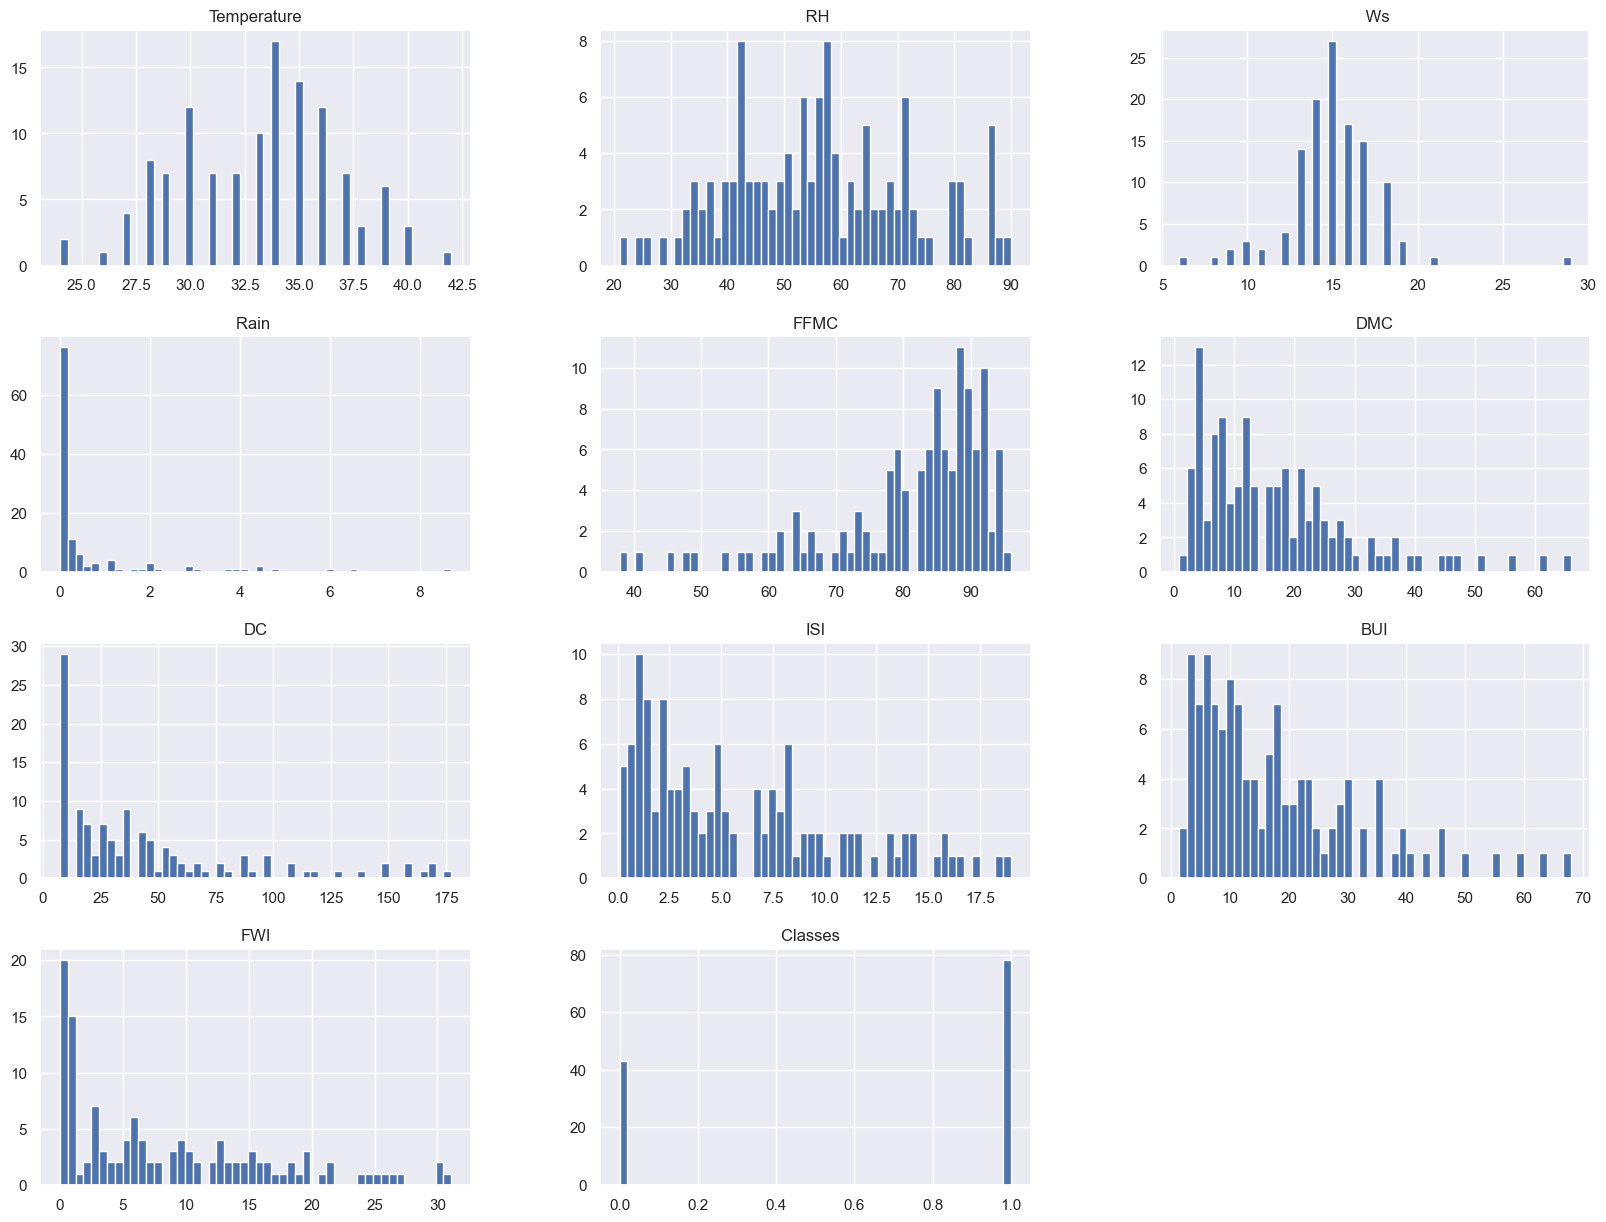

In [15]:
import seaborn as sns

sns.set_theme()
df_copy.hist(bins=50 ,figsize=(20 ,15))
plt.show()

In [16]:
percentage =df_copy['Classes  '].value_counts(normalize=True) *100

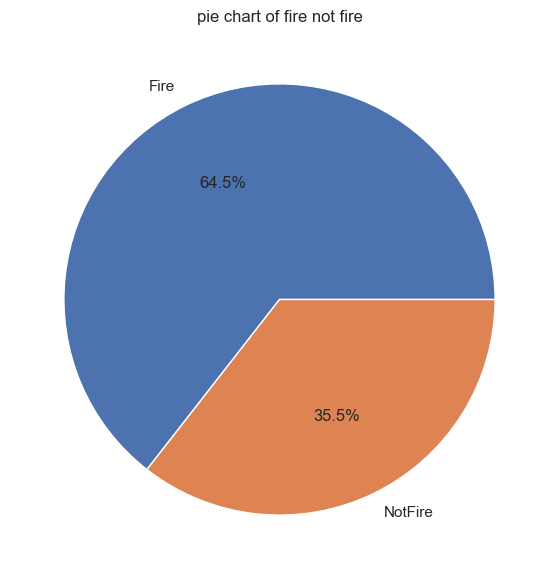

In [17]:
labels =["Fire" , "NotFire"]
plt.figure(figsize=(12, 7))

plt.pie(percentage , labels=labels ,autopct='%1.1f%%')
plt.title("pie chart of fire not fire")
plt.show()

<Axes: >

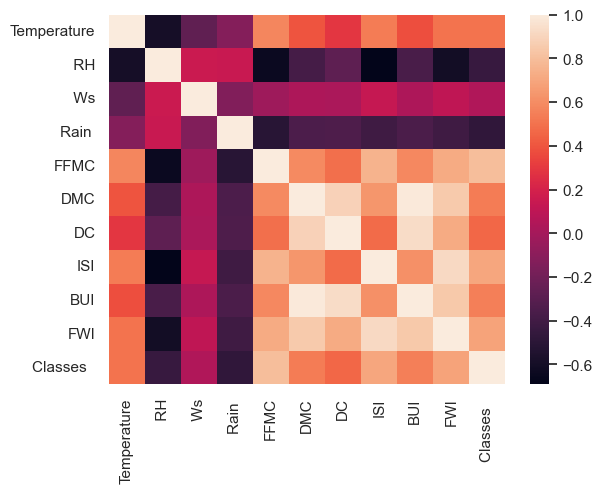

In [18]:
sns.heatmap(df_copy.corr())

<Axes: xlabel='month', ylabel='count'>

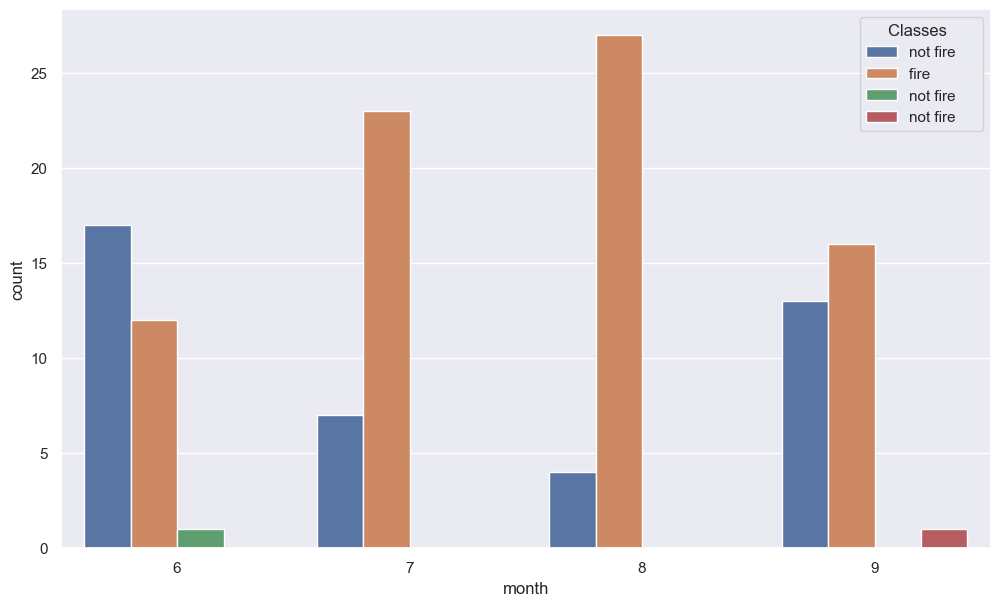

In [19]:
plt.subplots(figsize=(12 , 7))
sns.countplot(x='month' , hue='Classes  ' , data=df)

In [20]:
from sklearn.model_selection import train_test_split
df_copy

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,0
1,30,73,13,4.0,55.7,2.7,7.8,0.6,2.9,0.2,0
2,29,80,14,2.0,48.7,2.2,7.6,0.3,2.6,0.1,0
3,30,64,14,0.0,79.4,5.2,15.4,2.2,5.6,1.0,0
4,32,60,14,0.2,77.1,6.0,17.6,1.8,6.5,0.9,0
...,...,...,...,...,...,...,...,...,...,...,...
116,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1
117,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0
118,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0
119,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0


In [21]:
X = df_copy.drop('FWI' , axis=1)
y=df_copy['FWI']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.25 , random_state=42)

<Axes: >

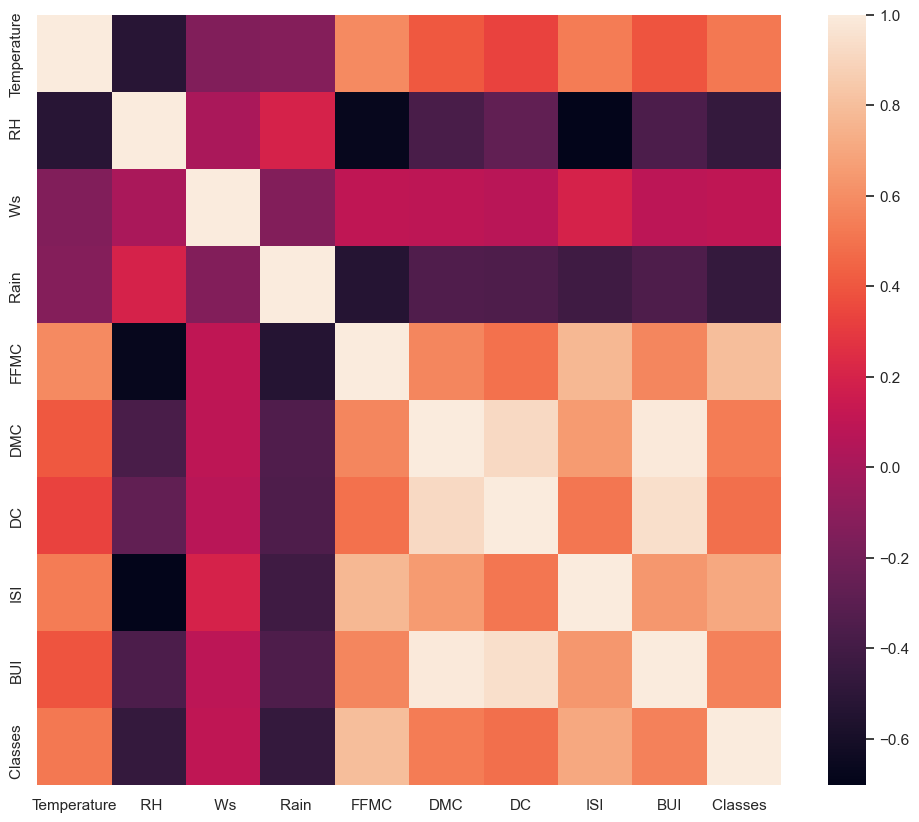

In [22]:
plt.figure(figsize=(12 , 10))
sns.heatmap(X_train.corr())

In [23]:
def coreelation(dataset , threshold):
    col_corr=set()
    corr_matrix=dataset.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr      

X_train.info()


<class 'pandas.DataFrame'>
Index: 90 entries, 78 to 102
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  90 non-null     int64  
 1    RH          90 non-null     int64  
 2    Ws          90 non-null     int64  
 3   Rain         90 non-null     float64
 4   FFMC         90 non-null     float64
 5   DMC          90 non-null     float64
 6   DC           90 non-null     float64
 7   ISI          90 non-null     float64
 8   BUI          90 non-null     float64
 9   Classes      90 non-null     int64  
dtypes: float64(6), int64(4)
memory usage: 7.7 KB


In [24]:
corr_features =  coreelation(X_train , 0.85)

X_train.drop(corr_features , axis=1 , inplace=True)
X_test.drop(corr_features , axis=1 , inplace=True)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler =StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

1.190702768496912


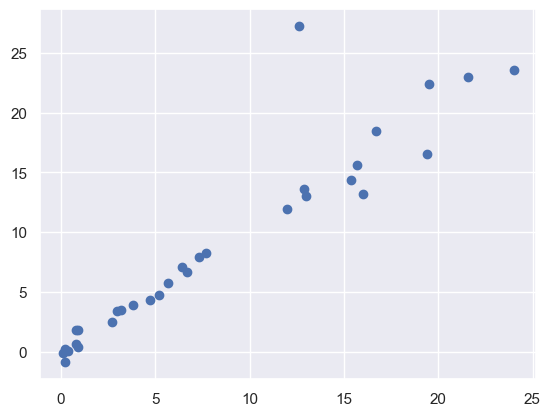

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , r2_score

model = LinearRegression()

model.fit(X_train_scaled , y_train)
y_pred = model.predict(X_test_scaled)


mae =mean_absolute_error(y_test , y_pred)

print(mae)

plt.scatter(y_test , y_pred)


1.3533285014629628


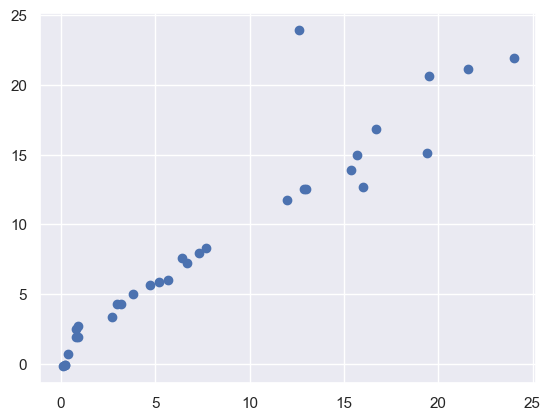

In [27]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error , r2_score

model2 = Lasso()

model2.fit(X_train_scaled , y_train)
y_pred = model2.predict(X_test_scaled)


mae =mean_absolute_error(y_test , y_pred)

print(mae)

plt.scatter(y_test , y_pred)

1.16138264916712
0.8534387597603872


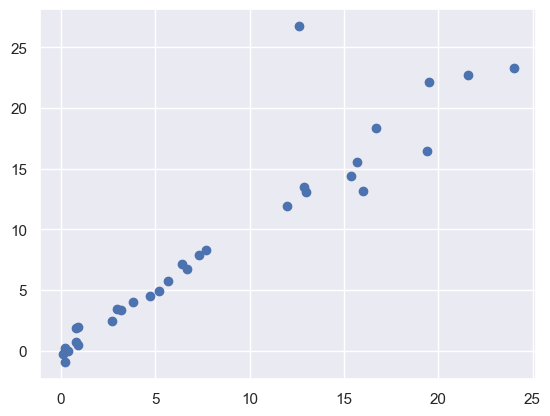

In [28]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error , r2_score

model1 =Ridge()

model1.fit(X_train_scaled , y_train)
y_pred = model1.predict(X_test_scaled)


mae =mean_absolute_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

print(mae)
print(r2)

plt.scatter(y_test , y_pred)

1.9014310977912212


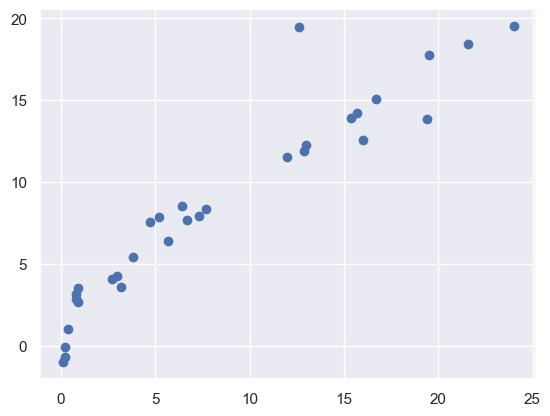

In [29]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error , r2_score

model3 = ElasticNet()

model3.fit(X_train_scaled , y_train)
y_pred = model3.predict(X_test_scaled)


mae =mean_absolute_error(y_test , y_pred)

print(mae)

plt.scatter(y_test , y_pred)

In [30]:
import pickle

pickle.dump(scaler ,open('scaler.pkl' , 'wb'))
pickle.dump(model1 ,open('ridge.pkl' , 'wb'))
